 # Trajectory analysis
 
This notebook is created to analyse the trajectory case series of the `SCENES` project.

## Imports and functions

In [3]:
import os
import re
import datetime
import math
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
# from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, LogLocator, FuncFormatter,  AutoMinorLocator , FixedLocator
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from pdf2image import convert_from_path
from matplotlib import rcParams
from cmcrameri import cm     #Scientific color maps
from itertools import cycle
from scipy.stats import ttest_1samp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import csv 
import gc
import random
from PIL import Image
from IPython.display import display, Markdown
import inspect

In [4]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [5]:
# Set default font properties
rcParams['font.family'] = 'Arial'
# Disable LaTeX rendering for text
rcParams['text.usetex'] = False  # This prevents LaTeX formatting in the tick labels
rcParams['font.size'] = 12

In [6]:
# Root path- project directory
root_dir = os.path.abspath("..")

In [7]:
# Color palettes

# Choose the color palette from cmcrameri
cmap = cm.batlow

# Define the custom color palette for photoreceptors
photoreceptor_colors = {
    'L cones': (0.8941, 0.1020, 0.1098),
    'M cones': (0.3020, 0.6863, 0.2902),
    'S cones': (0.2157, 0.4941, 0.7216),
    'Rods': (0.0157, 0.4118, 0.3333),
    'Melanopsin': (0.1255, 0.6549, 0.7686)   
}

In [52]:
# =========================================================
# Function for plotting the distribution of mean melanopic value of synthetic sequences
# =========================================================

def plot_model_timeline_iqr(
    sequences,
    placeholders=None,
    times=None,
    base_color=None,
    metric_name="Melanopic EDI",
    sequences_name=None,
    save_dir="../results/plots",
    dpi=300,
    show_median=False,
    ax=None,                 # NEW
    save=True,               # NEW
    add_top_axis=True,       # NEW
    show_legend=True,        # NEW
):

    sequences = np.asarray(sequences)
    n_slots, _ = sequences.shape

    if placeholders is None:
        placeholders = [f"PH{i+1:02d}" for i in range(n_slots)]
    if len(placeholders) != n_slots:
        raise ValueError("Length of `placeholders` must match sequences.shape[0].")

    x = np.arange(n_slots)

    mean = sequences.mean(axis=1)
    ymin = sequences.min(axis=1)
    ymax = sequences.max(axis=1)
    q25 = np.percentile(sequences, 25, axis=1)
    q75 = np.percentile(sequences, 75, axis=1)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
        created_fig = True
    else:
        fig = ax.figure

    if base_color is None:
        base_color = cm.batlow(0.6)

    # Range
    ax.fill_between(x, ymin, ymax, color=base_color, alpha=0.3, edgecolor="black", linewidth=0.5, label="Range", zorder=3)
    # IQR
    ax.fill_between(x, q25, q75, color=base_color, alpha=0.6, edgecolor="black", linewidth=0.5, label="IQR", zorder=5)
    # Mean
    ax.plot(
        x, mean,
        linewidth=3, marker="o",
        color=base_color, label="Mean",
        markeredgecolor="black", markeredgewidth=0.6,
        zorder=7
    )

    if show_median:
        med = np.median(sequences, axis=1)
        ax.plot(x, med, linestyle="-", marker=None, label="Median")

    # Bottom x-axis
    ax.set_xticks(x)
    ax.set_xticklabels(placeholders, rotation=45, ha="center", fontsize=9)
    ax.set_xlabel("Placeholder", fontsize=11)

    # Top x-axis (optional)
    ax_top = None
    if add_top_axis and (times is not None):
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(x)
        ax_top.set_xticklabels(times, rotation=45, ha="center", fontsize=9)
        ax_top.set_xlabel("Time of day", fontsize=11)

    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_yscale("log")
    ax.set_ylim(1e-1, 1e5)
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax.tick_params(axis="y", labelsize=10)

    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

    if show_legend:
        leg = ax.legend(loc="lower center", fontsize=9, frameon=False,handlelength=2, title=sequences_name)
        if leg and leg.get_title():
            leg.get_title().set_fontsize(10)

    # Only do tight_layout + saving when we created the figure here
    if created_fig:
        plt.tight_layout()
        if save and sequences_name:
            safe = str(sequences_name).replace(" ", "_")
            base = f"{save_dir}/Distribution_{safe}"
            fig.savefig(base + ".png", bbox_inches="tight", dpi=dpi)
            fig.savefig(base + ".pdf", bbox_inches="tight", dpi=dpi)

    stats = {"mean": mean, "q25": q25, "q75": q75}
    if show_median:
        stats["median"] = np.median(sequences, axis=1)

    return stats, ax_top


In [ ]:
# =========================================================
# Function for plotting the heatmap of median reletive error heatmap (monte carlo convergence) for differnt numbers of synthetic sequences
# =========================================================

def plot_monte_carlo_stability_heatmap(
    sequences,
    repeats=(100, 1000, 10000, 100000),
    n_runs=50,
    rel_threshold=0.01,
    metric_name="Melanopic-EDI",
    sequences_name=None,
    placeholders=None,
    seed=123,
    reference="full",        
    save_dir="../results/plots",
    dpi=300,
    vmax=5.0,
):
    """
    Heatmap of Monte Carlo convergence (median relative error, %) per placeholder.
    - X axis: placeholders
    - Y axis: repeats (r)
    - Cell value: median relative error (%) across n_runs
    - Fixed vmax (%) for comparability across models
    """
    sequences = np.asarray(sequences)
    n_slots, n_seq = sequences.shape
    repeats = list(repeats)

    if placeholders is None:
        placeholders = [f"PH{i+1:02d}" for i in range(n_slots)]
    if len(placeholders) != n_slots:
        raise ValueError("Length of `placeholders` must match sequences.shape[0].")

    rng = np.random.default_rng(seed)
    # Reference mean: full set
    ref_mean = sequences.mean(axis=1)

    # all_err: run x repeat x slot
    all_err = np.zeros((n_runs, len(repeats), n_slots), dtype=float)

    for j, r in enumerate(repeats):
        r_eff = min(int(r), n_seq)
        for b in range(n_runs):
            # Subsample already-generated sequences (columns)
            idx = rng.choice(n_seq, size=r_eff, replace=False)
            mean_r = sequences[:, idx].mean(axis=1)
            rel_err = np.abs(mean_r - ref_mean) / (np.abs(ref_mean) + 1e-12)
            all_err[b, j, :] = rel_err

    # Median across runs -> % ; shape: repeats x slots
    median_err = np.median(all_err, axis=0) * 100.0

    # ---- Plot  ----
    fig, ax = plt.subplots(figsize=(7, 3))

    im = ax.imshow(
        median_err,
        aspect="auto",
        interpolation="nearest",
        vmin=0.0,
        vmax=float(vmax),
        cmap=cm.batlow,
        alpha=0.9
    )

    # Axes: X = placeholders, Y = repeats
    ax.set_yticks(np.arange(len(repeats)))
    ax.set_yticklabels([rf"$10^{{{np.log10(r):.0f}}}$" for r in repeats], fontsize=9)
    ax.set_ylabel("Number of synthetic sequences ", fontsize=10)

    ax.set_xticks(np.arange(n_slots))
    ax.set_xticklabels(placeholders, rotation=45, ha="center", fontsize=8)
    ax.set_xlabel("Placeholder", fontsize=11)

    # Add thin borders around each cell
    ax.set_xticks(np.arange(-0.5, n_slots, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(repeats), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # ax.set_title(f"Monte Carlo convergence (median relative error, %) — {metric_name}", fontsize=11)

    # Mark cells meeting criterion (< threshold)
    thr_pct = rel_threshold * 100.0
    ok = median_err < thr_pct
    ys, xs = np.where(ok)
    ax.scatter(xs, ys, s=20, marker="o", facecolors="none", edgecolors="black", linewidths=0.8)

    # Text box: first line = sequence name, second line = criterion
    if sequences_name is None:
        seq_title = "Model"
    else:
        seq_title = str(sequences_name)

    ax.text(
        0.01, 0.99,
        f"Open circles: median relative error < {thr_pct:.1f}%",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.6", alpha=0.9)
    )

    # Compact colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("Median relative error (%)", rotation=90, fontsize=9)

    plt.tight_layout()

    # Save
    if sequences_name:
        safe_name = str(sequences_name).replace(" ", "_")
        file_base = f"{save_dir}/MonteCarlo_stability_heatmap_{safe_name}"
        fig.savefig(file_base + ".png", bbox_inches="tight", dpi=dpi)
        fig.savefig(file_base + ".pdf", bbox_inches="tight", dpi=dpi)

    return median_err, all_err

## Environmental spectral illuminance from Canada at three trajectory days

In [43]:
# Import environmental datasets

paths = [
    r"..\data\20230614RoofBox1min.csv",
    r"..\data\20230616RoofBox1min.csv",
    r"..\data\20230619RoofBox1min.csv",
]

env_illuminance_14_df , env_illuminance_16_df , env_illuminance_19_df= map(pd.read_csv, paths)

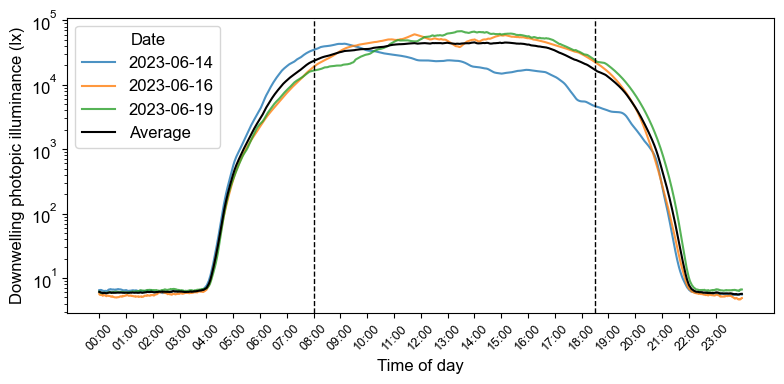

In [44]:
# Plot downwelling photopic illuminance for trajectory days (log scale )

plt.figure(figsize=(8, 4))

smoothed_series = []

for df in (env_illuminance_14_df, env_illuminance_16_df, env_illuminance_19_df):
    df = df.copy()
    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.sort_values("DateTime")

    x = df["DateTime"].dt.strftime("%H:%M")
    y = df["Out Ill (Lux)"]

    y_smooth = y.rolling(window=100, center=True, min_periods=1).mean()
    smoothed_series.append(y_smooth.values)

    label = df["DateTime"].dt.date.iloc[0].isoformat()
    plt.plot(x, y_smooth, alpha=0.8, label=label)

# --- average line ---
avg_y = np.mean(smoothed_series, axis=0)
plt.plot(x, avg_y, color="black", linewidth=1.5, label="Average")

# x-ticks every 1 hour (1-min data)
tick_pos = list(range(0, len(x), 60))
tick_lab = x.iloc[::60]
plt.xticks(tick_pos, tick_lab, rotation=45,fontsize=9)
plt.yscale('log')
plt.xlabel("Time of day")
plt.ylabel("Downwelling photopic illuminance (lx)")

plt.legend(title="Date")

# --- vertical reference lines ---
time_labels = x.tolist()

idx_0800 = time_labels.index("08:00")
idx_1830 = time_labels.index("18:30")

plt.axvline(idx_0800, color="black", linestyle="--", linewidth=1)
plt.axvline(idx_1830, color="black", linestyle="--", linewidth=1)

plt.tight_layout()

## Import Jeti-metadata file


In [8]:
# Dataset for merged metadata and spectral data (Jeti)

merged_metadata_jeti_df = pd.read_csv(r'..\data\metadata_jeti_scenes.csv', index_col=0, dtype={'time': str})

# Replace all NaN cells with blanks
merged_metadata_jeti_df = merged_metadata_jeti_df.fillna('')
merged_metadata_jeti_df.head()

,timestamp,project_id,project_name,project_start,data_curator,project_record,setup,device_geometry,measurement_id,record_id,date_x,time_x,protocol,available_$device,available_gloptic_spectis1,available_gigahertz-optic_msc15,available_jeti_spectraval1511,available_westborophotonics_wp690e-circ,wp690csv,available_kleininstruments_k-10a,available_inteldrealsense_d455,available_gopro_hero10black_video,available_gopro_hero10black_photo,location,latitude,longitude,direction,elevation,groundheight,boxtilt,boxheight,temperature,humidity,weather,other_weather,wind,scene,other_scene,view,other_view,lighting,other_lighting,technotes,available_all,date_y,time_y,Illuminance [lx] (CIE1931 2°),Irradiance [W/sqm] (380-780nm),Correlated Color Temp. (CCT) [K],Duv,dE2000 (CIE1931 2°),Dominant Wavelength (DWl) [nm] (CIE1931 2°),Color Purity (PE) [%] (CIE1931 2°),x,y,X,Y,Z,dE00,CCT [K],R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,Ra,Re,DC,VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8,VS9,VS10,VS11,VS12,VS13,VS14,VS15,Qa,Qf,Qp,Qg,Rf,Rg,Rf (general color fidelity index),Rf1,Rf2,Rf3,Rf4,Rf5,Rf6,Rf7,Rf8,Rf9,Rf10,Rf11,Rf12,Rf13,Rf14,Rf15,Rf16,Rf17,Rf18,Rf19,Rf20,Rf21,Rf22,Rf23,Rf24,Rf25,Rf26,Rf27,Rf28,Rf29,Rf30,Rf31,Rf32,Rf33,Rf34,Rf35,Rf36,Rf37,Rf38,Rf39,Rf40,Rf41,Rf42,Rf43,Rf44,Rf45,Rf46,Rf47,Rf48,Rf49,Rf50,Rf51,Rf52,Rf53,Rf54,Rf55,Rf56,Rf57,Rf58,Rf59,Rf60,Rf61,Rf62,Rf63,Rf64,Rf65,Rf66,Rf67,Rf68,Rf69,Rf70,Rf71,Rf72,Rf73,Rf74,Rf75,Rf76,Rf77,Rf78,Rf79,Rf80,Rf81,Rf82,Rf83,Rf84,Rf85,Rf86,Rf87,Rf88,Rf89,Rf90,Rf91,Rf92,Rf93,Rf94,Rf95,Rf96,Rf97,Rf98,Rf99,Begin Wavelength [nm],End Wavelength [nm],Ephot (Begin..End) [uMol/s sqm],"X e,mel [W/sqm]","X v,mel,D65 (MEDI) [lx]","a mel,v (MEER)","m v,mel,D65 (MDER)",EML [lx],CCT [K].1,Esc [W/sqm],Emc [W/sqm],Elc [W/sqm],Erh [W/sqm],Emel [W/sqm],Peak Wavelength [nm],PEAK FWHM [nm],Centroid Wavelength [nm],R,G,B,Ratio Value,Mv [380; 780],dE1,dE2,dE3,dE4,dE5,Result of relevant equation,Effective Irradiance [mW/sqm],Damage Potential [W/sqm*lx],Maximum exposure time [h],Eb [W/m²],"Kb,v [W/lm]",Kc,R bp/fs [%],R lb/tb [%],R nbp/bp [%]
0,20230208T0800,101,SCENES,20230208,Niloufar Tabandeh,1.0,Full setup,,1001,1001_20230208T0800,20230208,800,Timelapse,,0,0,1,1,1,1,1,1,1,Tübingen-DE,48.537222,9.058611,120SE,460,4,0,130,-3.5,55.1,Clear,,No wind,Outdoor (countryside),,Outdoor,,Outdoor (daylight),,,2,20230208,800,12728.4,86.5,2899.0,0.000,25.4,583.2,55.6,0.445,0.407,13902.0,12728.0,4637.0,131.8,2899.4,91.9,96.4,96.9,91.4,92.5,96.2,93.9,86.2,71.7,93.1,90.4,94.3,92.4,98.1,93.2,91.8,0.0,97.8,93.3,93.4,95.5,96.5,95.1,96.9,98.4,96.1,94.7,94.9,97.5,93.6,97.0,97.8,95.6,94.3,98.2,102.5,95.0,101.5,95.0,96.0,93.1,93.8,94.2,89.2,92.5,91.8,90.0,98.9,91.8,89.2,90.6,94.7,97.7,95.0,91.0,90.8,94.6,91.9,90.5,91.7,90.9,96.9,94.7,92.9,93.5,96.6,98.1,93.7,94.4,94.5,93.5,95.4,96.9,98.7,96.7,98.7,95.2,99.2,98.5,97.6,97.9,95.9,99.8,96.3,95.7,96.6,92.4,96.2,97.0,97.3,96.6,95.5,96.5,96.7,95.1,94.9,95.4,96.6,98.8,96.9,97.6,97.3,94.6,94.3,94.9,94.7,95.2,97.0,94.7,96.1,98.1,94.2,97.6,96.8,94.7,95.6,95.9,96.4,96.8,89.4,98.7,97.4,97.9,94.1,89.6,95.0,94.3,92.7,94.2,97.2,91.5,94.0,89.4,93.7,94.9,93.7,94.0,92.1,400.0,700.0,271.5,8.8,6658.9,0.5,0.5,7348.2,2899.4,3.3,15.1,21.1,11.1,8.8,777.0,83340.0,746.1,19320.4,11408.5,4566.1,0.5,2.9,3.1,3.4,2.0,4.6,1.6,0.0,35.1,0.0,142.6,4.0,0.000,0.5,5.1,29.1,451.6
1,20230208T0830,101,SCENES,20230208,Niloufar Tabandeh,2.0,Full setup,,1001,1001_20230208T0830,20230208,830,Timelapse,,0,0,1,0,0,1,1,1,1,Tübingen-DE,48.537222,9.058611,120SE,460,4,0,130,-2.1,50.8,Clear,,No wind,Outdoor (countryside),,Outdoor,,Outdoor (daylight),,,1,20230208,830,44447.0,227.6,3910.0,0.005,19.8,577.0,34.7,0.389,0.393,43913.0,44447.0,24647.0,134.0,3910.2,98.8,98.3,98.1,96.3,98.7,98.4,96.0,96.0,93.4,97.2,97.2,93.5,98.0,99.1,97.6,97.1,0.0,99.2,94.6,93.1,90.3,92.4,92.6,94.6,95.4,98.2,98.2,96.1,94.9,94.0,97.0,98.5,94.7,94.8,94.6,97.4,94.9,97.7,94.9,98.2,96.7,95.0,96.0,94.8,97.6,97.8,97.1,98.4,95.9,94.8,95.5,97.0,98.4,94.3,94.0,93.6,94.4,93.9,89.1,93.2,90.9,95.7,94.4,9

## Trajectory data frame, measured light exposures

In [9]:
# Trajectory section (Three trajectory days dataset)

trajectory_canada_df = merged_metadata_jeti_df[
    (merged_metadata_jeti_df['protocol'] == 'Trajectory') &
    (merged_metadata_jeti_df['location'] == 'Ottawa-CA')
]
trajectory_canada_df.shape

(63, 235)

In [10]:
# Make a copy from trajectory dataset

copy_trajectory_canada_df = trajectory_canada_df.copy()

# Convert timestamp to datetime
copy_trajectory_canada_df['datetime'] = pd.to_datetime(copy_trajectory_canada_df['timestamp'], format='%Y%m%dT%H%M')
copy_trajectory_canada_df['date'] = copy_trajectory_canada_df['datetime'].dt.date
copy_trajectory_canada_df['time'] = copy_trajectory_canada_df['datetime'].dt.time

In [11]:
# Pivot table for `Photopic illuminance` and `melanopic EDI` values

metrics = [
    'Illuminance [lx] (CIE1931 2°)',
    'X v,mel,D65 (MEDI) [lx]' 
]

# Pivot table: one row per time, columns = date × metric
pivot_photopic_melanopic_trajectory_canada_df = copy_trajectory_canada_df.pivot_table(
    index='time',      # rows = time only
    columns='date',    # columns = dates
    values=metrics,    # metrics to pivot
    aggfunc='first'     # take the first value for each time/date (we have just one value for each timestamp)
).reset_index()

# Rename metrics
rename_map = {
    'Illuminance [lx] (CIE1931 2°)': 'Photopic illuminance (lx)',
    'X v,mel,D65 (MEDI) [lx]': 'Melanopic EDI (lx)'
}
pivot_photopic_melanopic_trajectory_canada_df = pivot_photopic_melanopic_trajectory_canada_df.rename(columns=rename_map, level=0)

# Replace NaNs with empty string
pivot_photopic_melanopic_trajectory_canada_df = pivot_photopic_melanopic_trajectory_canada_df.fillna("")
pivot_photopic_melanopic_trajectory_canada_df.to_csv(r'..\results\pivot_photopic_melanopic_trajectory_canada.csv', index=False)
pivot_photopic_melanopic_trajectory_canada_df

time Photopic illuminance (lx)                        \
date                          2023-06-14 2023-06-16 2023-06-19   
0     08:00:00                      36.1       37.3       43.8   
1     08:30:00                     130.2      110.0      114.1   
2     09:00:00                    4553.4    15976.8     6286.0   
3     09:30:00                   15164.0    14620.2    11627.8   
4     09:45:00                    7540.7                         
5     10:00:00                   12543.8    14606.9    12254.8   
6     10:30:00                     464.6      154.2     3768.2   
7     11:00:00                     493.4      154.9     4047.0   
8     11:30:00                     421.9      155.9     4429.0   
9     12:00:00                     379.3      156.7     4311.8   
10    12:30:00                     359.1      156.2     3715.6   
11    13:00:00                    4904.2    15422.8    34813.6   
12    13:30:00                     639.1      941.1     1353.8   
13    14:00:00                     327.5      161.6     6518.5   
14    14:30:00                     279.3      165.1     7671.7   
15    15:00:00                     325.8      165.4     7671.2   
16    15:30:00                     251.5      165.8     8977.6   
17    16:00:00                    5845.9    12023.0     8389.2   
18    16:30:00                    8367.5    15424.6              
19    17:00:00                    1500.3     2813.6              
20    17:30:00                      63.8       27.0       31.4   
21    18:00:00                      37.2       33.4       61.8   
22    18:30:00                      35.9                         

     Melanopic EDI (lx)                        
date         2023-06-14 2023-06-16 2023-06-19  
0                  19.0       20.4       23.0  
1                  92.0       70.8       81.1  
2                4227.6    14421.8     6155.2  
3               14287.4    13535.0    10942.8  
4                7474.6                        
5               11539.1    13503.6    11466.1  
6                 355.0       93.2     3527.1  
7                 378.2       93.5     3858.5  
8                 320.2       93.9     4130.5  
9                 286.4       94.5     4171.3  
10                269.7       94.3     3421.9  
11               4439.6    14938.9    33750.6  
12                551.7      845.3     1185.9  
13                248.2       97.9     6252.4  
14                207.8       99.9     7325.8  
15                245.8      100.5     7678.2  
16                185.7      100.6     8660.9  
17               5553.3    10945.2     7783.4  
18               7709.9    14772.3             
19               1408.0     2715.7             
20                 47.1       22.2       24.2  
21                 18.4       24.4       46.3  
22                 17.5

In [78]:
# Pivot table for trajectory melanopic EDI values and two metadata entries ( scenes + lighting) 

metric_col = 'X v,mel,D65 (MEDI) [lx]'  # only this metric

# pivots
p_edi = copy_trajectory_canada_df.pivot_table(
    index="time", columns="date", values=metric_col, aggfunc="first"
)

p_scene = copy_trajectory_canada_df.pivot_table(
    index="time", columns="date", values="scene", aggfunc="first"
)

p_lighting = copy_trajectory_canada_df.pivot_table(
    index="time", columns="date", values="lighting", aggfunc="first"
)

# combine -> columns as (date, subheader)
out = pd.concat(
    {"Melanopic EDI (lx)": p_edi, "scene": p_scene, "lighting": p_lighting},
    axis=1
).swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

pivot_melanopic_with_metadata_df = out.reset_index().fillna("")
pivot_melanopic_with_metadata_df.to_csv(r'..\results\pivot_melanopic_metadata_trajectory_canada.csv', index=False)


In [12]:
# Extract dates (first 8 characters: yyyymmdd)

trajectory_canada_dates = copy_trajectory_canada_df['date'].astype(str).unique().tolist()
trajectory_canada_dates

['2023-06-14', '2023-06-16', '2023-06-19']

In [14]:
# Create summary table for number of `Indoor` and `Outdoor` measurements 

grouped_df = copy_trajectory_canada_df.groupby(['date', 'view']).size().reset_index(name='count')

# Create a new column 'type' based on 'view'
grouped_df['index'] = grouped_df['view'].apply(lambda x: 'outdoor' if x == 'Outdoor' else 'indoor')

# Pivot the DataFrame to have 'Outdoor' and 'Indoor' as separate columns
pivot_summary_df = grouped_df.pivot_table(index='date', columns='index', values='count', aggfunc='sum', fill_value=0).reset_index()
# Add a 'Total' column to sum up counts for each date
pivot_summary_df['sum'] = pivot_summary_df[['indoor', 'outdoor']].sum(axis=1)

summary_row = {
    'date': 'total',
    'indoor': pivot_summary_df['indoor'].sum(),
    'outdoor': pivot_summary_df['outdoor'].sum(),
    'sum': pivot_summary_df['sum'].sum()
}
pivot_summary_df = pd.concat(
    [pivot_summary_df, pd.DataFrame([summary_row])],
    ignore_index=True
)
pivot_summary_df.index = pivot_summary_df.index + 1
pivot_summary_df.to_csv(r'..\results\pivot_summary_trajectory_canada.csv', index=False)
pivot_summary_df

,date,indoor,outdoor,sum
1,2023-06-14,16,7,23
2,2023-06-16,14,7,21
3,2023-06-19,15,4,19
4,total,45,18,63


### Photopic illuminance

In [15]:
# Descriptive statistics ( Photopic illuminance)

# Group by time and compute mean, min, max, Q1, Q3, and IQR
photopic_stats = copy_trajectory_canada_df.groupby('time')['Illuminance [lx] (CIE1931 2°)'].agg(
    mean='mean',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
# Add IQR column
photopic_stats['iqr'] = photopic_stats['q3'] - photopic_stats['q1']

# Round mean to 2 decimals
photopic_stats['mean'] = photopic_stats['mean'].round(2)

# Reset index if needed
photopic_stats = photopic_stats.reset_index()
photopic_stats

,time,mean,min,max,q1,q3,iqr
0,08:00:00,39.07,36.1,43.8,36.700,40.550,3.85
1,08:30:00,118.10,110.0,130.2,112.050,122.150,10.10
2,09:00:00,8938.73,4553.4,15976.8,5419.700,11131.400,5711.70
3,09:30:00,13804.00,11627.8,15164.0,13124.000,14892.100,1768.10
4,09:45:00,7540.70,7540.7,7540.7,7540.700,7540.700,0.00
5,10:00:00,13135.17,12254.8,14606.9,12399.300,13575.350,1176.05
6,10:30:00,1462.33,154.2,3768.2,309.400,2116.400,1807.00
7,11:00:00,1565.10,154.9,4047.0,324.150,2270.200,1946.05
8,11:30:00,1668.93,155.9,4429.0,288.900,2425.450,2136.55
9,12:00:00,1615.93,156.7,4311.8,268.000,2345.550,2077.55


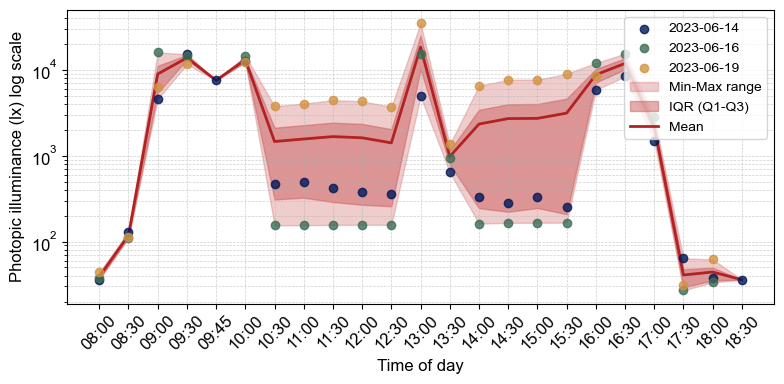

In [91]:
# Plot photopic illuminance throughout trajectory days

fig, ax = plt.subplots(figsize=(8,4))

scatter_handles = []  # to collect scatter handles for legend
colors = [cm.batlow(i/len(copy_trajectory_canada_df['date'].unique())) for i in range(len(copy_trajectory_canada_df['date'].unique()))]

# Plot each day's measurements as scatter
for i, date in enumerate(copy_trajectory_canada_df['date'].unique()):
    day_data = copy_trajectory_canada_df[copy_trajectory_canada_df['date'] == date]
    sc = ax.scatter(
        [t.strftime('%H:%M') if not isinstance(t, str) else t[:5] for t in day_data['time']],
        day_data['Illuminance [lx] (CIE1931 2°)'],
        color=colors[i],
        alpha=0.8,
        zorder=4
    )
    scatter_handles.append((sc, str(date)))  # store handle + label

# Fill area between Q1 and Q3 (IQR)
iqr_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['q1'],
    photopic_stats['q3'],
    color='indianred',
    alpha=0.5,
    zorder=1,
    label='IQR (Q1-Q3)'
)

# Fill area between min and max
minmax_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['min'],
    photopic_stats['max'],
    color='indianred',
    alpha=0.3,
    zorder=0,
    label='Min-Max'
)

# Overlay mean lines
mean_line, = ax.plot(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['mean'],
    color='firebrick',
    linewidth=2,
    label='Mean',
    zorder=3
)

# Create legend: one handle per day + fill + mean
handles = [h for h, l in scatter_handles] + [minmax_fill, iqr_fill, mean_line]
labels = [l for h, l in scatter_handles] + ['Min-Max range', 'IQR (Q1-Q3)', 'Mean']

ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=10)

# Log scale
ax.set_yscale('log')
# Labels and title
ax.set_xlabel('Time of day')
ax.set_ylabel('Photopic illuminance (lx) log scale')
#ax.set_title('Photopic illuminance per measurement day')
# Grid with minor lines
ax.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.6, zorder=0)

# Format x-axis ticks
plt.xticks(rotation=45)
plt.tight_layout()

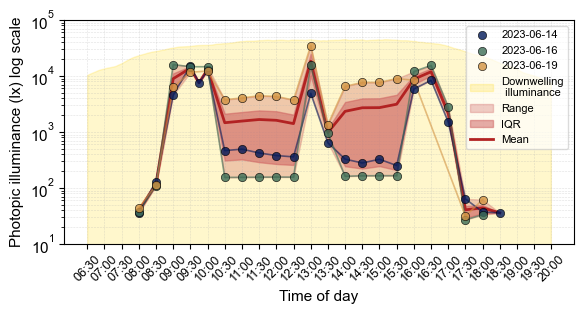

In [92]:
# Plot photopic illuminance throughout trajectory days + Downwelling illuminance (log scale)

fig, ax = plt.subplots(figsize=(6, 3.3))

# =========================================================
# ENVIRONMENTAL AVERAGE → Downwelling photopic illuminance
# =========================================================
smoothed_series = []
x_env = None

for df in (env_illuminance_14_df, env_illuminance_16_df, env_illuminance_19_df):
    d = df.copy()
    d["DateTime"] = pd.to_datetime(d["DateTime"])
    d = d.sort_values("DateTime")

    # restrict to 06:00–20:30
    d = d[
        (d["DateTime"].dt.time >= pd.to_datetime("06:30").time()) &
        (d["DateTime"].dt.time <= pd.to_datetime("20:00").time())
    ]

    x = d["DateTime"].dt.strftime("%H:%M")
    y = d["Out Ill (Lux)"].astype(float)

    y_smooth = y.rolling(window=100, center=True, min_periods=1).mean()
    smoothed_series.append(y_smooth.values)

    if x_env is None:
        x_env = x.values

# pointwise average
env_avg = np.mean(smoothed_series, axis=0)

downwelling_fill = ax.fill_between(
    x_env,
    1,                 # log-safe baseline
    env_avg,
    color="gold",
    alpha=0.2,
    zorder=0,
    label="Downwelling illuminance"
)

# =========================================================
# PHOTOPIC ILLUMINANCE
# =========================================================
scatter_handles = []
unique_dates = copy_trajectory_canada_df["date"].unique()
colors = [cm.batlow(i / len(unique_dates)) for i in range(len(unique_dates))]

for i, date in enumerate(unique_dates):
    day_data = copy_trajectory_canada_df[
        copy_trajectory_canada_df["date"] == date
    ]
    # ADD LINE
    ax.plot(
        [t.strftime("%H:%M") if not isinstance(t, str) else t[:5]
        for t in day_data["time"]],
        day_data["Illuminance [lx] (CIE1931 2°)"],
        color=colors[i],
        alpha=0.6,
        linewidth=1.2,
         zorder=6
    )
    sc = ax.scatter(
        [t.strftime("%H:%M") if not isinstance(t, str) else t[:5]
         for t in day_data["time"]],
        day_data["Illuminance [lx] (CIE1931 2°)"],
        color=colors[i],
        edgecolors="black",
        linewidth=0.5,
        alpha=0.8,
        zorder=7
    )
    scatter_handles.append((sc, str(date)))

# --- Min–Max ---
minmax_fill = ax.fill_between(
    [t.strftime("%H:%M") for t in photopic_stats["time"]],
    photopic_stats["min"],
    photopic_stats["max"],
    color="indianred",
    alpha=0.3,
    zorder=1,
    label="Range"
)

# --- IQR ---
iqr_fill = ax.fill_between(
    [t.strftime("%H:%M") for t in photopic_stats["time"]],
    photopic_stats["q1"],
    photopic_stats["q3"],
    color="indianred",
    alpha=0.5,
    zorder=2,
    label="IQR"
)

# --- Mean ---
mean_line, = ax.plot(
    [t.strftime("%H:%M") for t in photopic_stats["time"]],
    photopic_stats["mean"],
    color="firebrick",
    linewidth=2,
    zorder=5,
    label="Mean"
)

# =========================================================
# FORMATTING (30-min ticks)
# =========================================================

ax.set_xlabel("Time of day", fontsize=11)
# half-hour ticks
tick_times = pd.date_range("06:30", "20:00", freq="30min").strftime("%H:%M")
ax.set_xticks(tick_times)
plt.xticks(rotation=45, fontsize=9)

ax.set_yscale("log")
ax.set_ylabel("Photopic illuminance (lx) log scale", fontsize=11)
ax.set_ylim(1e1, 1e5)
plt.yticks( fontsize=11)


handles = (
    [h for h, _ in scatter_handles] +
    [downwelling_fill, minmax_fill, iqr_fill, mean_line]
)
labels = (
    [l for _, l in scatter_handles] +
    ["Downwelling\n illuminance", "Range", "IQR", "Mean"]
)

ax.legend(handles=handles, labels=labels, loc="upper right", fontsize=8, framealpha=0.7)

ax.grid(which="both", linestyle="--", linewidth=0.4, alpha=0.4, zorder=0)

plt.tight_layout()

### Melanopic EDI

In [16]:
# Descriptive statistics ( Melanopic EDI)

# Group by time and compute mean, min, max, Q1, Q3, and IQR
melanopic_stats = copy_trajectory_canada_df.groupby('time')['X v,mel,D65 (MEDI) [lx]'].agg(
    mean='mean',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
# Add IQR column
melanopic_stats['iqr'] = melanopic_stats['q3'] - melanopic_stats['q1']

# Round mean to 2 decimals
melanopic_stats['mean'] = melanopic_stats['mean'].round(2)

# Reset index if needed
melanopic_stats = melanopic_stats.reset_index()
melanopic_stats

,time,mean,min,max,q1,q3,iqr
0,08:00:00,20.80,19.0,23.0,19.700,21.700,2.00
1,08:30:00,81.30,70.8,92.0,75.950,86.550,10.60
2,09:00:00,8268.20,4227.6,14421.8,5191.400,10288.500,5097.10
3,09:30:00,12921.73,10942.8,14287.4,12238.900,13911.200,1672.30
4,09:45:00,7474.60,7474.6,7474.6,7474.600,7474.600,0.00
5,10:00:00,12169.60,11466.1,13503.6,11502.600,12521.350,1018.75
6,10:30:00,1325.10,93.2,3527.1,224.100,1941.050,1716.95
7,11:00:00,1443.40,93.5,3858.5,235.850,2118.350,1882.50
8,11:30:00,1514.87,93.9,4130.5,207.050,2225.350,2018.30
9,12:00:00,1517.40,94.5,4171.3,190.450,2228.850,2038.40


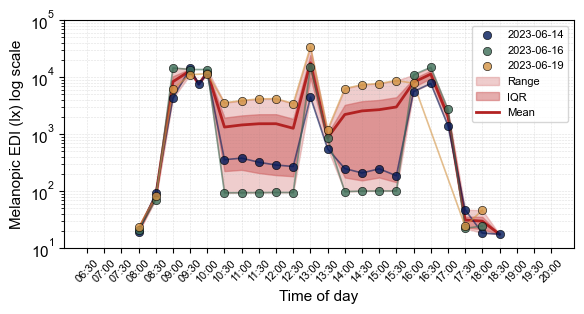

In [94]:
# Plot Melanopic EDI throughout trajectory days

fig, ax = plt.subplots(figsize=(6,3.3))

# --- helper: convert "time of day" to datetime on a dummy date ---
BASE_DATE = pd.Timestamp("2000-01-01")

def to_dt_timeofday(t):
    if isinstance(t, str):
        # expects "HH:MM..." strings
        return pd.to_datetime(f"{BASE_DATE.date()} {t[:5]}")
    # datetime.time / pandas Timestamp
    return pd.to_datetime(f"{BASE_DATE.date()} {t.strftime('%H:%M')}")

scatter_handles = []
unique_dates = copy_trajectory_canada_df["date"].unique()
colors = [cm.batlow(i / len(unique_dates)) for i in range(len(unique_dates))]

# =========================================================
# MELANOPIC EDI per day: line + scatter
# =========================================================
for i, date in enumerate(unique_dates):
    day_data = copy_trajectory_canada_df[copy_trajectory_canada_df["date"] == date].copy()

    x_day = pd.to_datetime([to_dt_timeofday(t) for t in day_data["time"]])
    y_day = day_data["X v,mel,D65 (MEDI) [lx]"].astype(float).values

    # ensure time-sorted within day
    order = np.argsort(x_day.values)
    x_day = x_day[order]
    y_day = y_day[order]

    ax.plot(
        x_day, y_day,
        color=colors[i],
        alpha=0.6,
        linewidth=1.2,
        zorder=6
    )

    sc = ax.scatter(
        x_day, y_day,
        color=colors[i],
        edgecolors="black",
        linewidth=0.5,
        alpha=0.8,
        zorder=7
    )
    scatter_handles.append((sc, str(date)))

# =========================================================
# STATS: Range, IQR, Mean
# =========================================================
x_stats = pd.to_datetime([to_dt_timeofday(t) for t in melanopic_stats["time"]])

minmax_fill = ax.fill_between(
    x_stats,
    melanopic_stats["min"].astype(float),
    melanopic_stats["max"].astype(float),
    color="indianred",
    alpha=0.3,
    zorder=1,
    label="Range"
)

iqr_fill = ax.fill_between(
    x_stats,
    melanopic_stats["q1"].astype(float),
    melanopic_stats["q3"].astype(float),
    color="indianred",
    alpha=0.5,
    zorder=2,
    label="IQR"
)

mean_line, = ax.plot(
    x_stats,
    melanopic_stats["mean"].astype(float),
    color="firebrick",
    linewidth=2,
    zorder=5,
    label="Mean"
)

# =========================================================
# AXIS FORMATTING: 06:30–20:00, ticks every 30 min
# =========================================================
ax.set_yscale("log")
ax.set_ylim(1e1, 1e5)
plt.yticks(fontsize=11)
ax.set_ylabel("Melanopic EDI (lx) log scale", fontsize=11)

ax.set_xlabel("Time of day", fontsize=11)
xmin = BASE_DATE + pd.Timedelta(hours=5, minutes=50)   #  padding before
xmax = BASE_DATE + pd.Timedelta(hours=20, minutes=40) #  padding after
ax.set_xlim(xmin, xmax)

# half-hour ticks + HH:MM labels
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45, fontsize=8)
tick_times = pd.date_range("2000-01-01 06:30", "2000-01-01 20:00", freq="30min")
ax.set_xticks(tick_times)

# legend
handles = [h for h, _ in scatter_handles] + [minmax_fill, iqr_fill, mean_line]
labels  = [l for _, l in scatter_handles] + ["Range", "IQR", "Mean"]
ax.legend(handles=handles, labels=labels, loc="upper right", fontsize=8)


# y-grid only (drops x-grid)
ax.grid(which="both", linestyle="--", linewidth=0.4, alpha=0.4, zorder=0)

plt.tight_layout()

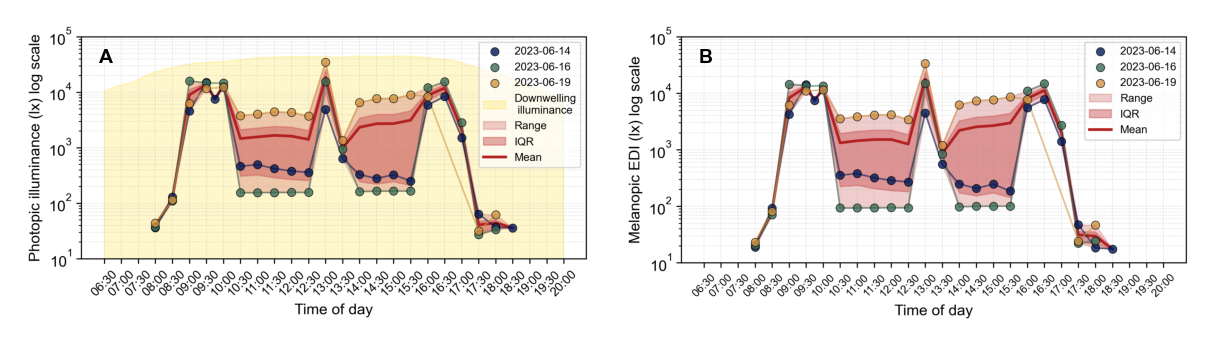

In [95]:
# Figure Photopic, melanopic
# paths
p1 = "../results/plots/photopic_illuminance_trajectory_days.png"
p2 = "../results/plots/melanopic_trajectory_days.png"

# read images
im1 = Image.open(p1)
im2 = Image.open(p2)

# figure
fig, axs = plt.subplots(1, 2, figsize=(12, 3.3))

axs[0].imshow(im1)
axs[1].imshow(im2)

for ax in axs:
    ax.axis("off")

# panel labels
axs[0].text(
    0.15, 0.88, "A",
    transform=axs[0].transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)

axs[1].text(
    0.15, 0.88, "B",
    transform=axs[1].transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)

plt.tight_layout(pad=0.1, w_pad=0.2)
fig.savefig("../results/plots/plot_photopic_melanopic.png", dpi=300)
fig.savefig("../results/plots/plot_photopic_melanopic.pdf", dpi=300)

### Photopic illuminance vr Melanopic EDI

In [96]:
# Pearson correlation coefficient

correlation_coefficient = trajectory_canada_df['Illuminance [lx] (CIE1931 2°)'].corr(trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'])

print( f" Correlation Coefficient between mEDI and Illuminance from Jeti: {correlation_coefficient}")

 Correlation Coefficient between mEDI and Illuminance from Jeti: 0.9995190290327606


In [97]:
# Create a new column 'in/out' based on 'view'
trajectory_canada_df['in/out'] = trajectory_canada_df['view'].apply(lambda x: 'Outdoor' if x.startswith('Outdoor') else 'Indoor')


C:\Users\ntabandeh\AppData\Local\Temp\ipykernel_7080\2618375490.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trajectory_canada_df['in/out'] = trajectory_canada_df['view'].apply(lambda x: 'Outdoor' if x.startswith('Outdoor') else 'Indoor')
C:\Users\ntabandeh\AppData\Local\Temp\ipykernel_7080\2618375490.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_canada_df['in/out'] = trajectory_canada_df['view'].apply(lambda x: 'Outdoor' if x.startswith('Outdoor') else 'Indoor')


In [98]:
# Calculate correlation coefficient for Indoor data

# Calculate correlation coefficient for Indoor data
indoor_data = trajectory_canada_df[trajectory_canada_df['in/out'] == 'Indoor']
correlation_indoor = indoor_data['Illuminance [lx] (CIE1931 2°)'].corr(indoor_data['X v,mel,D65 (MEDI) [lx]'])

# Calculate correlation coefficient for Outdoor data
outdoor_data = trajectory_canada_df[trajectory_canada_df['in/out'] == 'Outdoor']
correlation_outdoor = outdoor_data['Illuminance [lx] (CIE1931 2°)'].corr(outdoor_data['X v,mel,D65 (MEDI) [lx]'])

# Print the results
print(f"Correlation Coefficient for Indoor data: {correlation_indoor}")
print(f"Correlation Coefficient for Outdoor data: {correlation_outdoor}")

Correlation Coefficient for Indoor data: 0.9996614058418479
Correlation Coefficient for Outdoor data: 0.9991835426132162


In [99]:
# Plot mEDI for each day in one plot, log10 scale (Jeti)

# Get a colormap and normalize it based on the number of groups
  
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))

plt.figure(figsize = (10,7)) 

x_values = set()

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    
    jeti_values = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    
    color = cmap(norm(i))  # Get a color based on the index of the group
    plt.plot(group_df['time'], jeti_values, label=f'date_{group}', color=color)
    plt.scatter(group_df['time'], jeti_values, marker='o', color=color)
    
    # Collect unique x values with corresponding y values
    valid_x_values = group_df.loc[~np.isnan(jeti_values), 'time'].unique()
    x_values.update(valid_x_values)
    
# Convert set to a sorted list
x_values = sorted(x_values)
plt.xticks(x_values, rotation=45)
plt.yscale('log')    
plt.xlabel('Time')
plt.ylabel('log(mEDI [lx])')
plt.title('mEDI from Jeti in log scale')
plt.legend(loc='upper right');

#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_mEDI_Trajectory.pdf',dpi = 600, bbox_inches='tight');

KeyError: 'date'

In [ ]:
# Plot illuminace and mEDI for each day in log scale (Jeti)

# Get a colormap and normalize it based on the number of groups
cmap_ill = mpl.colormaps['winter']  
cmap_medi = mpl.colormaps['autumn'] 
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))


for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    plt.figure(figsize = (8,5))  # Create a new figure for each group
    
    color_illuminance = cmap_ill(norm(i))

    color_medi = cmap_medi(norm(i))
        
    jeti_illuminance = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'])
    
    plt.plot(group_df['time'], group_df['Illuminance [lx] (CIE1931 2°)'], label='Illuminance', color=color_illuminance)
    plt.scatter(group_df['time'], group_df['Illuminance [lx] (CIE1931 2°)'], marker='o', color=color_illuminance)
    
    jeti_medi = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    
    plt.plot(group_df['time'], group_df['X v,mel,D65 (MEDI) [lx]'], label='mEDI', alpha = 0.8, color=color_medi)
    plt.scatter(group_df['time'], group_df['X v,mel,D65 (MEDI) [lx]'], marker='o', alpha = 0.8, color=color_medi)
    
    plt.yscale('log')
    plt.xlabel('Time')
    plt.xticks(rotation=45)
    plt.ylabel('log[lx]')
    plt.title(f'Photopic illuminance and mEDI from Jeti in log scale_date{group}')
    plt.legend(loc='upper right');

    # Adjust layout for better spacing
    plt.tight_layout()
    
    #plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Trajectory_{group}.pdf', dpi = 600, bbox_inches="tight");

In [ ]:
# Plot illuminace and mEDI ratio in one plot for all days in one plot (Jeti)

# Get a colormap and normalize it based on the number of groups 
 
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))
plt.figure(figsize = (10,7))
x_values = set()

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    
    illuminance_values = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'])
    medi_values = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    ratio_values = illuminance_values / medi_values
    
    color = cmap(norm(i))
    
    plt.plot(group_df['time'], ratio_values, label=f'date_{group}', color=color)
    plt.scatter(group_df['time'], ratio_values, marker='o', color=color)
    # Collect unique x values with corresponding y values
    valid_x_values = group_df.loc[~np.isnan(ratio_values), 'time'].unique()
    x_values.update(valid_x_values)
    
# Convert set to a sorted list
x_values = sorted(x_values)
plt.xticks(x_values, rotation=45)
      
plt.xlabel('Time')
plt.ylabel('Ratio (illuminance/mEDI)')
plt.title('Photopic illuminance and mEDI ratio from Jeti')
plt.legend(loc='upper center');

# Adjust layout for better spacing
plt.tight_layout()

#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Trajectory_ratio.pdf', dpi = 600, bbox_inches="tight");

In [ ]:
# Plot illumnance vr mEDI for all trajectory days in one plot (Jeti)

plt.figure(figsize=(6, 6)) 
for group, group_df in trajectory_canada_df.groupby('date'):
    # Drop rows with NaN values in the specified columns
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    
    scatter_plot = plt.scatter(x_values, y_values, label=group)
    

# Perform linear regression for y = mx + b
model = LinearRegression()
model.fit(x_values, y_values)
    
# Get regression line parameters
m = model.coef_[0]
b = model.intercept_

# Generate x values for the regression line
regression_line_x = np.linspace(0, x_values, 100).reshape(-1, 1)
    
# Calculate corresponding y values for the regression line
regression_line_y = m * regression_line_x + b
    
# Plot the regression line
plt.plot(regression_line_x, regression_line_y, color='black', label=f'y = {m:.2f}x + {b:.2f}')

# Perform linear regression for y = m2x
model_new = LinearRegression()
model_new.fit(x_values, y_values)

# Get regression line parameters for the new line
m2 = model_new.coef_[0]

# Calculate corresponding y values for the new regression line (y = mx)
regression_line_y_new = m2 * regression_line_x

# Plot the new regression line
plt.plot(regression_line_x, regression_line_y_new, color='red', label=f'y = {m:.2f}x')
    
# Set limits based on the current plot's maximum value
plt.xlim(0)
plt.ylim(0)
plt.xlabel('mEDI [lx]')
plt.ylabel('Illuminance [lx]')
plt.legend(loc = 'upper left')
plt.title(f'Illuminance vr mEDI for trajectory days');


In [ ]:

plt.figure(figsize=(6, 6)) 
for group, group_df in trajectory_canada_df.groupby('date'):
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    max_value = y_values.max()
    
    scatter_plot = plt.scatter(x_values, y_values, label=group)

# Perform linear regression for log-transformed values
model = LinearRegression()
model.fit(np.log10(x_values), np.log10(y_values))
    
    # Get regression line parameters
m = model.coef_[0]
b = model.intercept_

    # Generate log-transformed x values for the regression line
regression_line_x = np.linspace(x_values.min(), x_values.max(), 100)
regression_line_x_log = np.log10(regression_line_x)    
# Calculate corresponding log-transformed y values for the regression line
regression_line_y_log = m * regression_line_x_log + b
regression_line_y = 10 ** regression_line_y_log
# Plot the regression line
plt.plot(regression_line_x, regression_line_y, color='black', label=f'log fit, y = {b:.2f}+ {m:.2f}x')

# Perform linear regression for y = m2x
model_new = LinearRegression()
model_new.fit(np.log10(x_values), np.log10(y_values))

# Get regression line parameters for the new line
m2 = model_new.coef_[0]

# Calculate corresponding y values for the new regression line (y = mx)
regression_line_y_new = m2 * regression_line_x

# Plot the new regression line
plt.plot(regression_line_x, regression_line_y_new, color='red', label=f'log fit, y = {m2:.2f}x')



plt.xscale('log')  # Set x-axis to log scale
plt.yscale('log')  # Set y-axis to log scale

plt.xlabel('log(mEDI [lx])')
plt.ylabel('log(Illuminance [lx])')
plt.legend(loc='upper left')
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)
plt.title(f'Illuminance vr mEDI in log 10 for trajectory days');


#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Illuminance_vr_mEDI.pdf', dpi = 600, bbox_inches='tight');

In [ ]:
# Create subplots for two groups
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for (group, group_df), ax in zip(trajectory_canada_df.groupby('in/out'), [ax1, ax2]):
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    max_value = y_values.max()
    
    scatter_plot = ax.scatter(x_values, y_values, label=group)

    # Perform linear regression for log-transformed values
    model = LinearRegression()
    model.fit(np.log10(x_values), np.log10(y_values))
    
    # Get regression line parameters
    m = model.coef_[0]
    b = model.intercept_

    # Generate log-transformed x values for the regression line
    regression_line_x = np.linspace(x_values.min(), x_values.max(), 100).reshape(-1, 1)
    regression_line_x_log = np.log10(regression_line_x)    
    # Calculate corresponding log-transformed y values for the regression line
    regression_line_y_log = m * regression_line_x_log + b
    regression_line_y = 10 ** regression_line_y_log
    # Plot the regression line
    ax.plot(regression_line_x, regression_line_y, color='black', label=f'logaritmic fit, y = {b:.2f}+ {m:.2f}x')

    # Perform linear regression for y = m2x
    model_new = LinearRegression()
    model_new.fit(np.log10(x_values), np.log10(y_values))

    # Get regression line parameters for the new line
    m2 = model_new.coef_[0]

    # Calculate corresponding y values for the new regression line (y = mx)
    regression_line_y_new = m2 * regression_line_x

    # Plot the new regression line
    ax.plot(regression_line_x, regression_line_y_new, color='red', label=f'logaritmic fit, y = {m2:.2f}x')

    ax.set_xscale('log')  # Set x-axis to log scale
    ax.set_yscale('log')  # Set y-axis to log scale

    ax.set_xlabel('log(mEDI [lx])')
    ax.set_ylabel('log(Illuminance [lx])')
    ax.legend(loc='upper left')
    ax.grid(True, which='minor', linestyle='--', linewidth=0.5)
    ax.set_title(f'Illuminance vs mEDI for {group} trajectory days')
    # Set x and y limits explicitly
    ax.set_xlim(10, 1e5)
    ax.set_ylim(10, 1e5)
plt.tight_layout()

#plt.savefig('results/trajectories/trajectory_plots/Jeti_Illuminance_vr_mEDI_inout.pdf', dpi = 600, bbox_inches='tight');

## Next step: Now I want table for fit and error. Not correct, will check it later

In [ ]:
# Select the columns of interest
x_column = 'X v,mel,D65 (MEDI) [lx]'
y_column = 'Illuminance [lx] (CIE1931 2°)'

# Drop NaN values from the selected columns
cleaned_df = trajectory_canada_df[[x_column, y_column]].dropna()

In [ ]:

# Perform linear regression for y = mx + b
tidy_trajectory_canada_df = trajectory_canada_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])

x_values = tidy_trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
y_values = tidy_trajectory_canada_df['Illuminance [lx] (CIE1931 2°)'].values

model = LinearRegression()
model.fit(x_values, y_values)
    
# Get regression line parameters
slope = model.coef_[0]
intercept = model.intercept_

# Calculate variance (mean squared error)
predictions = model.predict(x_values)
variance = mean_squared_error(y_values, predictions)

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print (f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
print(f"Variance (Mean Squared Error): {variance:.2f}")

In [ ]:
# Select the columns of interest
x_column = 'X v,mel,D65 (MEDI) [lx]'
y_column = 'Illuminance [lx] (CIE1931 2°)'

# Drop NaN values from the selected columns
tidy_trajectory_canada_df = tidy_trajectory_canada_df.dropna(subset=[x_column, y_column, 'in/out'])

# Group by 'in/out' and perform linear regression for each group
for group, group_df in tidy_trajectory_canada_df.groupby('in/out'):
    # Extract the x and y values for the current group
    x_values = group_df[x_column].values.reshape(-1, 1)
    y_values = group_df[y_column].values

    # Perform linear regression
    model = LinearRegression()
    model.fit(x_values, y_values)

    # Get regression line parameters
    slope = model.coef_[0]
    intercept = model.intercept_

    # Calculate variance (mean squared error)
    predictions = model.predict(x_values)
    variance = mean_squared_error(y_values, predictions)

    print(f"Group: {group}")
    print(f"Slope: {slope:.2f}")
    print(f"Intercept: {intercept:.2f}")
    print(f'y = {slope:.2f}x + {intercept:.2f}')
    print(f"Variance (Mean Squared Error): {variance:.2f}")
    print()

In [ ]:
tidy_trajectory_canada_df

In [ ]:
# Calculate the number of combinations
n = 63
r = 21
num_combinations = math.comb(n, r)

# Print the result
print(f"The number of possible combinations is: {num_combinations}")

In [ ]:
# Calculate the number of combinations
n = 63
r = 8
num_combinations = math.comb(n, r)

# Print the result
print(f"The number of possible combinations is: {num_combinations}")

## Trajectory models, synthetic sequences


In [48]:
# Define the trajectory bins as placeholders for the synthetic days (22 time slots)

placeholders = ['MH01', 'MH02', 'MC03', 'MC04', 'MC05', 'MO06', 'MO07', 'MO08', 'MO09', 'MO10', 'NN11', 'NN12', 'AO13', 'AO14', 'AO15', 'AO16', 'AC17', 'AC18', 'AC19', 'AH20', 'AH21', 'AH22']
len(placeholders)

22

In [ ]:
# Generate 22 timeslot labels (08:00, 18:30) correspond to 22 placeholders

times = [f"{h:02d}:{m:02d}" for h, m in
     [(8,0),(8,30),(9,0),(9,30),(10,0),(10,30),(11,0),(11,30),
     (12,0),(12,30),(13,0),(13,30),(14,0),(14,30),(15,0),(15,30),
     (16,0),(16,30),(17,0),(17,30),(18,0),(18,30)]]


### Naive model

In [66]:
# 100000 sequence, random sampling with permutation of 63 melanopic EDI values in 22 placeholders. 

np.random.seed(20)
n_sequences = 100000  # number of synthetic sequences
n_slots = len(placeholders)
melanopic_values = copy_trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'].dropna().values
# Generate all sequences at once
naive_sequences = np.array([np.random.choice(melanopic_values, size=n_slots) 
                          for _ in range(n_sequences)]).T 

# Create DataFrame in one shot
naive_synthetic_df = pd.DataFrame(naive_sequences, index=placeholders,
                            columns=[f'seq_{i+1:04d}' for i in range(n_sequences)])

# synthetic_df now has placeholders as index and sequences as columns
print(naive_synthetic_df.shape)
naive_synthetic_df.iloc[:, :10].head()

naive_synthetic_df.to_csv(r'..\results\tables\naive_melanopic_sequence.csv')


(22, 100000)


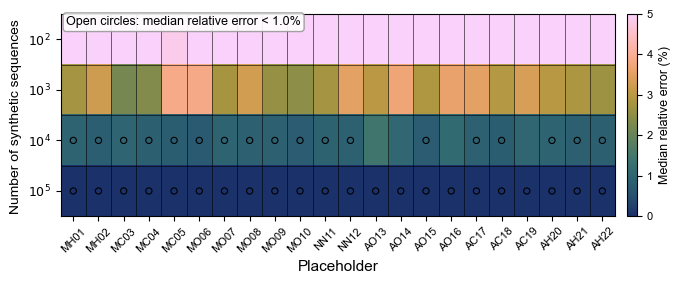

In [ ]:
# Plot heatmap of median reletive error heatmap (monte carlo convergence) for Naive model

median_err, all_err = plot_monte_carlo_stability_heatmap(
    naive_sequences,
    rel_threshold=0.01,
    sequences_name="naive_model_monte_carlo_convergence",
    placeholders=placeholders,
    save_dir="../results/plots",
    dpi=300
)

### Naive indoor model

In [61]:
# 100000 sequence, random sampling with permutation of 20 melanopic-EDI values in 22 placeholders.
np.random.seed(20)
# Number of synthetic sequences
n_sequences = 100000
n_slots = len(placeholders)

# 1. Filter indoor values
indoor_df = copy_trajectory_canada_df[copy_trajectory_canada_df['view'].str.contains('Indoor', na=False)]

# 2. Extract melanopic values from indoor data only
indoor_melanopic = indoor_df['X v,mel,D65 (MEDI) [lx]'].dropna().values

# 3. Generate sequences: randomly draw indoor values into all placeholders
naive_indoor_sequences = np.array([
    np.random.choice(indoor_melanopic, size=n_slots)
    for _ in range(n_sequences)
]).T   # shape: (22, n_sequences)

# 4. Create synthetic DataFrame
indoor_synthetic_df = pd.DataFrame(
    naive_indoor_sequences,
    index=placeholders,
    columns=[f'seq_{i+1:04d}' for i in range(n_sequences)]
)
print(indoor_synthetic_df.shape)
indoor_synthetic_df.iloc[:, :10].head()

indoor_synthetic_df.to_csv(r'..\results\tables\naive_indoor_melanopic_sequence.csv')

(22, 100000)


### Naive outdoor model

In [62]:
# 100000 sequence, random sampling with permutation of 43 melanopic-EDI values in 22 placeholders.
n_sequences = 100000
n_slots = len(placeholders)

# 1. Filter indoor values
outdoor_df = copy_trajectory_canada_df[copy_trajectory_canada_df['view'].str.contains('Outdoor', na=False)]

# 2. Extract melanopic values from indoor data only
outdoor_melanopic = outdoor_df['X v,mel,D65 (MEDI) [lx]'].dropna().values

# 3. Generate sequences: randomly draw indoor values into all placeholders
naive_outdoor_sequences = np.array([
    np.random.choice(outdoor_melanopic, size=n_slots)
    for _ in range(n_sequences)
]).T   # shape: (22, n_sequences)

# 4. Create synthetic DataFrame
outdoor_synthetic_df = pd.DataFrame(
    naive_outdoor_sequences,
    index=placeholders,
    columns=[f'seq_{i+1:04d}' for i in range(n_sequences)]
)
print(outdoor_synthetic_df.shape)
outdoor_synthetic_df.iloc[:, :10].head()

outdoor_synthetic_df.to_csv(r'..\results\tables\naive_outdoor_melanopic_sequence.csv')

(22, 100000)


### Time restricted model

In [27]:
df = copy_trajectory_canada_df.copy()
df['datetime'] = pd.to_datetime(df['datetime'])  

# create 22 fixed half-hour bin starts from 07:59 for mid measured day
bin_starts = pd.date_range("2023-06-16 07:59", periods=22, freq="30min").time

# collect values per bin (no new df columns)
mel_bins = []
for start in bin_starts:
    end = (pd.Timestamp("2000-01-01 " + start.strftime("%H:%M")) + pd.Timedelta(minutes=30)).time()
    mask = (df['datetime'].dt.time >= start) & (df['datetime'].dt.time < end)
    vals = df.loc[mask, 'X v,mel,D65 (MEDI) [lx]'].dropna().values
    mel_bins.append(vals)

In [63]:
n_sequences = 100000
n_slots = len(mel_bins)   # should be 22

# Generate sequences: one random value from bin i → placeholder i
time_restricted_sequences = np.zeros((n_slots, n_sequences))

for i, bin_values in enumerate(mel_bins):
    bin_values = np.array(bin_values)
    if len(bin_values) == 0:
        raise ValueError(f"Bin {i} is empty. Cannot sample.")
    time_restricted_sequences[i] = np.random.choice(bin_values, size=n_sequences, replace=True)

# Create DataFrame
time_restricted_df = pd.DataFrame(
    time_restricted_sequences,
    index=placeholders, 
    columns=[f"seq_{i+1:04d}" for i in range(n_sequences)]
)
print(time_restricted_df.shape)
time_restricted_df.iloc[:, :10].head()

time_restricted_df.to_csv(r'..\results\tables\time_restricted_melanopic_sequence.csv')

(22, 100000)


### Location restricted model

In [29]:

# Extract hour + minute as float for easier comparison
df['hour_min'] = df['datetime'].dt.hour * 100 + df['datetime'].dt.minute

# Create empty column for placeholder group
df['location_group'] = ''

# Morning (before 12.99 ~ 12:59)
morning_mask = df['hour_min'] <= 1259
afternoon_mask = df['hour_min'] >= 1359
noon_mask = (df['hour_min'] > 1259) & (df['hour_min'] < 1359)

# Morning placeholders
df.loc[morning_mask & df['scene'].str.contains('Indoor') & ~df['scene'].str.contains('office', case=False),
       'location_group'] = 'MH'  # Morning Home
df.loc[morning_mask & df['scene'].str.contains('Indoor') & df['scene'].str.contains('office', case=False),
       'location_group'] = 'MO'  # Morning Office
df.loc[morning_mask & df['scene'].str.contains('Outdoor'),
       'location_group'] = 'MC'  # Morning Commute

# Afternoon placeholders
df.loc[afternoon_mask & df['scene'].str.contains('Indoor') & ~df['scene'].str.contains('office', case=False),
       'location_group'] = 'AH'  # Afternoon Home
df.loc[afternoon_mask & df['scene'].str.contains('Indoor') & df['scene'].str.contains('office', case=False),
       'location_group'] = 'AO'  # Afternoon Office
df.loc[afternoon_mask & df['scene'].str.contains('Outdoor'),
       'location_group'] = 'AC'  # Afternoon Commute

# Noon placeholders
df.loc[noon_mask, 'location_group'] = 'NN'  # Noon

In [30]:
# Extract melanopic values per activity category
group_to_values = {}

for g in ['MH','MO','MC','AH','AO','AC','NN']:
    vals = df.loc[df['location_group'] == g, 'X v,mel,D65 (MEDI) [lx]'].dropna().values
    group_to_values[g] = vals.astype(float)
# Merge categories based on your mapping
location_map = {
    'H': ['MH', 'AH'],    # Home
    'O': ['MO', 'AO'],    # Office
    'C': ['MC', 'AC'],    # Commute
    'N': ['NN']           # Noon
}
# Build final pools
location_pool = {}
for key, groups in location_map.items():
    merged = np.concatenate([group_to_values[g] for g in groups if len(group_to_values[g]) > 0])
    location_pool[key] = merged

In [64]:
n_sequences = 100000  # number of synthetic sequences
outfile = r"..\results\tables\location_restricted_melanopic_sequence.csv"
# Map each placeholder to its activity type (second character)
placeholder_location = []
for ph in placeholders:
    if ph[:2] == 'NN':  # noon placeholders
        placeholder_location.append('N')
    else:
        placeholder_location.append(ph[1])  # H, O, C

# Initialize matrix
location_restricted_sequences = np.zeros((len(placeholders), n_sequences))

# Fill each placeholder row from the merged activity pool
for i, loc in enumerate(placeholder_location):
    pool = location_pool[loc]  # H, O, C, or N
    location_restricted_sequences[i, :] = np.random.choice(pool, size=n_sequences)

# Convert to DataFrame
location_restricted_df = pd.DataFrame(location_restricted_sequences, index=placeholders,
                      columns=[f"seq_{i+1:05d}" for i in range(n_sequences)])

# Save CSV
location_restricted_df.to_csv(outfile)
print("Done.")

Done.


### Time/location restricted model

In [32]:
# All time-activity groups in your labeling scheme
codes = ['MH','MO','MC','AH','AO','AC','NN']

time_location_pool = {}
for code in codes:
    vals = df.loc[df['location_group'] == code,
                  'X v,mel,D65 (MEDI) [lx]'].dropna().values
    time_location_pool[code] = vals.astype(float)


In [65]:
n_sequences = 100000
chunk_size = 1000
outfile = r"..\results\tables\time_location_restricted_melanopic_sequence.csv"

# Each placeholder draws from its exact pool (AO → AO, MH → MH, etc.)
time_location_restricted_sequences = np.zeros((len(placeholders), n_sequences))

for i, ph in enumerate(placeholders):
    pool = time_location_pool[ph[:2]]  # first two letters = time + activity
    time_location_restricted_sequences[i, :] = np.random.choice(pool, size=n_sequences)

# Convert to DataFrame: rows = placeholders, columns = sequences
time_location_restricted_df = pd.DataFrame(time_location_restricted_sequences, index=placeholders,
                      columns=[f"seq_{i+1:05d}" for i in range(n_sequences)])

# Save to CSV
time_location_restricted_df .to_csv(outfile)
print("Done.")

Done.


### Tailored model

### Plot synthetic model distributions

In [34]:
sequence_dict = {
    "naive_model": naive_sequences,
    "naive_indoor_model": naive_indoor_sequences,
    "naive_outdoor_model": naive_outdoor_sequences,
    "time_restricted_model": time_restricted_sequences,
    "location_restricted_model": location_restricted_sequences,
    "time_location_restricted_model": time_location_restricted_sequences,
}

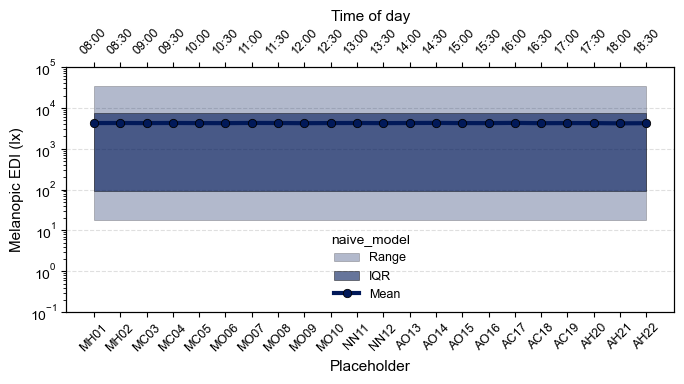

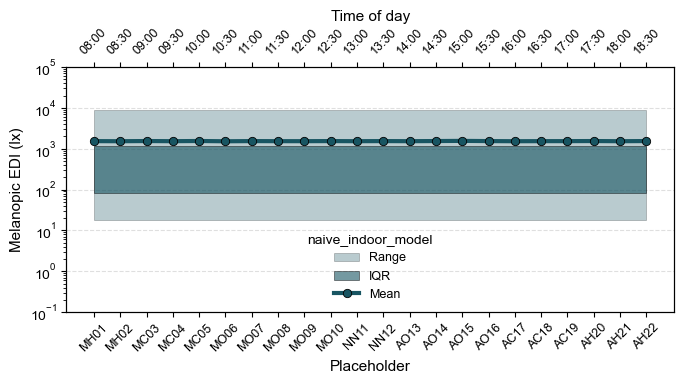

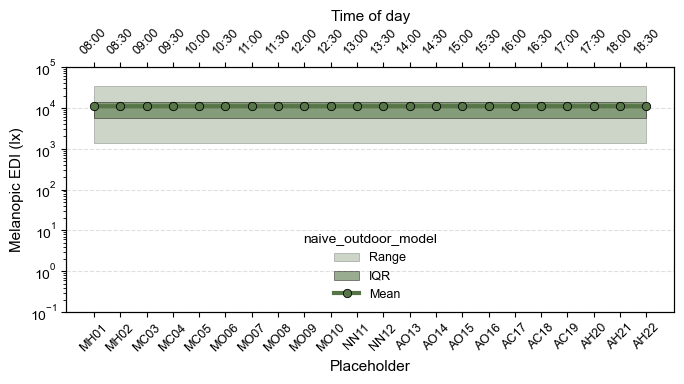

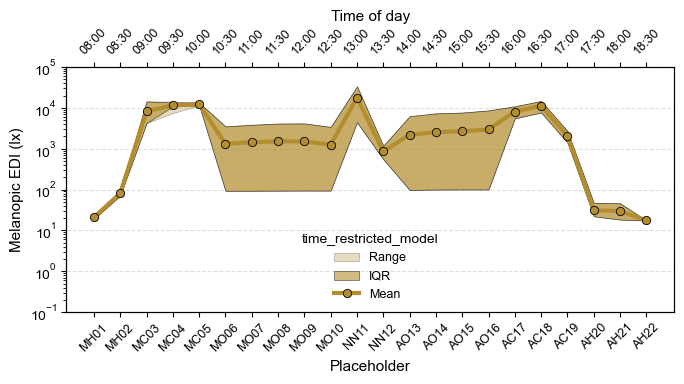

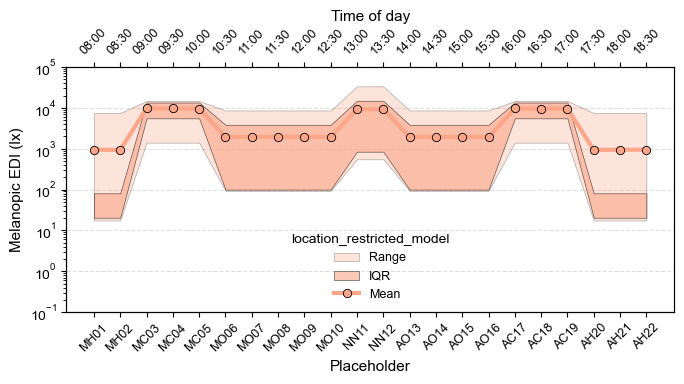

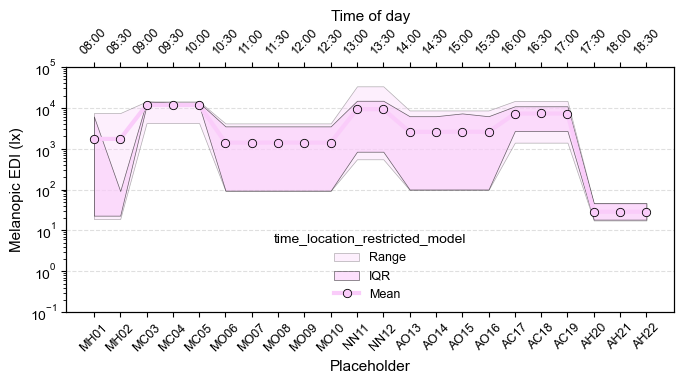

In [53]:
# Plot distribution of average melanopic EDI for six synthetic models throughout a synthetic day

keys = list(sequence_dict.keys())
n = len(keys)

for i, key in enumerate(keys):
    sequences = sequence_dict[key]

    # Color: first model gets first palette colour, etc.
    color_pos = i / max(n - 1, 1)
    base_color = cm.batlow(color_pos)

    plot_model_timeline_iqr(
        sequences,
        placeholders=placeholders,
        times=times,
        base_color=base_color,
        metric_name="Melanopic EDI (lx)",
        sequences_name=key,
        save_dir="../results/plots",
        dpi=300,
        show_median=False,
        ax=None,                        # create its own figure
        save=True,                      # save files
        add_top_axis=True,
        show_legend=True
    )

## Model comparison

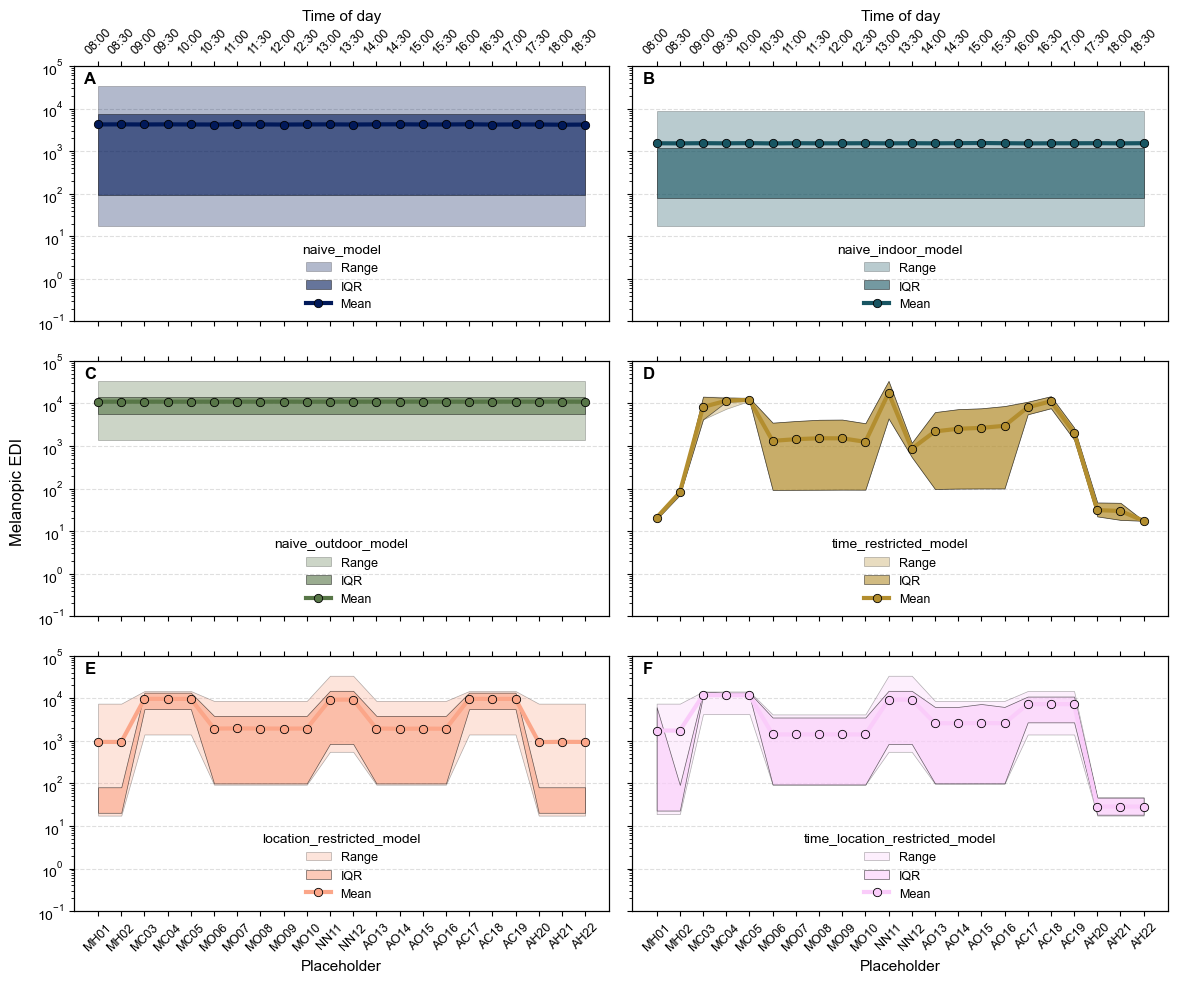

In [55]:
# Plot distribution of average melanopic EDI for six synthetic models throughout a synthetic day in one grid

# Model sequences as inputs
keys = list(sequence_dict.keys())
n = len(keys)
if n > 6:
    raise ValueError("Grid supports up to 6 models (3×2).")

# Grid 3*2
fig, axs = plt.subplots(3, 2, figsize=(12, 10), sharey=True)
axs = axs.flatten()
colors = [cm.batlow(i / max(n - 1, 1)) for i in range(n)]

for i, ax in enumerate(axs):
    if i >= n:
        ax.axis("off")
        continue

    key = keys[i]
    base_color = colors[i]

    # plot into this axis; do NOT save individual plots
    _, ax_top = plot_model_timeline_iqr(
        sequence_dict[key],
        placeholders=placeholders,
        times=times,
        base_color=base_color,
        metric_name="Melanopic EDI",
        sequences_name=key,
        ax=ax,
        save=False,
        add_top_axis=True,
        show_legend=True,
    )

    # panel label
    ax.text(0.02, 0.98, "ABCDEF"[i], transform=ax.transAxes,
            va="top", ha="left", fontsize=12, fontweight="bold")

    row, col = divmod(i, 2)

    # bottom x labels only on last row
    if row < 2:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

    # top x labels only on first row
    if ax_top is not None and row > 0:
        ax_top.set_xlabel("")
        ax_top.tick_params(axis="x", labeltop=False)

    # y tick labels only on left column; no per-panel y-label
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelleft=(col == 0))

# shared y label + save
fig.supylabel(metric_name, fontsize=12)
fig.tight_layout()
fig.savefig("../results/plots/Models_distribution_grid.png", dpi=300)
fig.savefig("../results/plots/Models_distribution_grid.pdf", dpi=300)

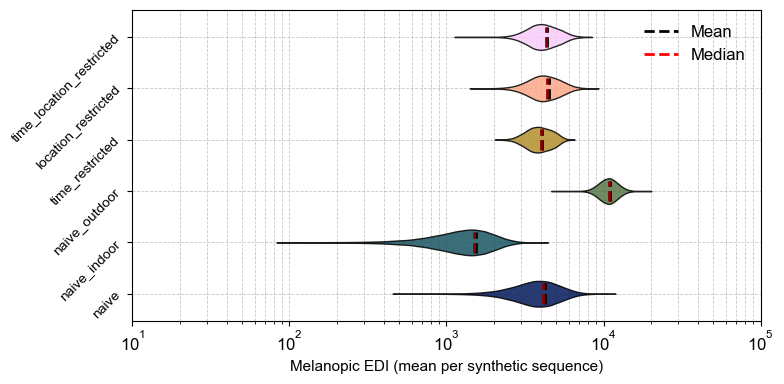

In [ ]:
# Violin plot of distribution of mean melanopic EDI for synthetic models

# Path of synthetic sequences
folder = "../results/tables"

# exact order of files (the unique part of filename before .csv)
model_order = [ 
    "naive_melanopic_sequence",
    "naive_indoor_melanopic_sequence",
    "naive_outdoor_melanopic_sequence",
    "time_restricted_melanopic_sequence",
    "location_restricted_melanopic_sequence",
    "time_location_restricted_melanopic_sequence"
]

all_model_means = []
model_labels = []

for model_name in model_order:
    # construct the full filename (assuming *.csv)
    fname = [f for f in os.listdir(folder) if model_name in f.lower()]
    if len(fname) == 0:
        continue  # skip missing files
    fname = fname[0]  # take the first match
    label = fname.lower().replace(".csv", "")  # label for plot
    model_labels.append(label)

    # read CSV memory-safe
    df = pd.read_csv(os.path.join(folder, fname))
    df_numeric = df.iloc[:, 1:]  # drop first column (non-numeric index)
    col_means = df_numeric.mean(axis=0).values
    all_model_means.append(col_means)

    del df, df_numeric
    gc.collect()

# ----------------- PLOT -----------------
fig, ax = plt.subplots(figsize=(8, 4))
n = len(all_model_means)

# put grid behind
ax.set_axisbelow(True)

# categorical colors
colors = [cmap(i / (n - 1)) for i in range(n)] if n > 1 else [cmap(0.5)]

# violins
parts = ax.violinplot(all_model_means, showmeans=False, showextrema=False, vert=False)

for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(colors[i])
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_zorder(2)  # put violins above grid
# mean and median lines
for i, col in enumerate(all_model_means):
    pos = i + 1
    mean_val = np.mean(col)
    median_val = np.median(col)
    ax.plot( [mean_val, mean_val], [pos - 0.2, pos + 0.2], color='black', linewidth=2, linestyle='--', label='Mean' if i==0 else "", zorder=3)
    ax.plot( [median_val, median_val], [pos - 0.2, pos + 0.2], color='darkred', linewidth=2, linestyle='--', label='Median' if i==0 else "", zorder=3)

# x-axis labels: remove '_melanopic_sequence'

ax.set_xscale("log")
ax.set_xlim(1e1, 1e5)
ax.set_xlabel("Melanopic EDI (mean per synthetic sequence)", fontsize=11)


# y-axis log scale and grid `if i want to ordered y axis top to bottom: (ax.invert_yaxis()),`
y_labels = [label.replace("_melanopic_sequence", "") for label in model_labels]
ax.set_yticks(range(1, n + 1))
ax.set_yticklabels(y_labels, ha="right", fontsize=10, rotation=45)

#ax.set_title("Model Comparison — Synthetic Sequence Mean Distributions")
ax.grid(which="both", linestyle="--", linewidth=0.6, alpha=0.7, zorder=1)

# legend
mean_line = Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Mean')
median_line = Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Median')
ax.legend(handles=[mean_line, median_line], loc='upper right', frameon=False)

plt.tight_layout()
fig.savefig("../results/plots/Violin_plot_mean_melanopic_distribution.png", dpi=300)
fig.savefig("../results/plots/Violin_plot_mean_melanopic_distribution.pdf", dpi=300)

## Real world light exposure dataset


In [ ]:
# read CSV
real_world_df = pd.read_csv(r'..\data\real_world_dataset.csv')
# Add time if missing
real_world_df["Datetime"] = real_world_df["Datetime"].apply(
    lambda x: x if ":" in x else f"{x} 00:00"
)
real_world_df["Datetime"] = pd.to_datetime(real_world_df["Datetime"], format="%d.%m.%Y %H:%M")
real_world_df.head()

In [ ]:
df_day = real_world_df[
    (real_world_df["Datetime"].dt.time >= pd.to_datetime("08:00").time()) &
    (real_world_df["Datetime"].dt.time <= pd.to_datetime("18:30").time())
]
df_day = df_day[df_day["MEDI"] >= 0.9]


In [ ]:
# get sorted list of sites
sites = sorted(df_day["Site"].unique())

all_site_values = []
site_labels = []

for site in sites:
    vals = df_day.loc[df_day["Site"] == site, "MEDI"].dropna().values
    if len(vals) == 0:
        continue
    all_site_values.append(vals)
    site_labels.append(site)

In [ ]:
# Group by site and get min/max with corresponding times
site_summary = []

for site in df_day["Site"].unique():
    df_site = df_day[df_day["Site"] == site]
    if df_site.empty:
        continue

    total_count = len(df_site)
    
    # min MEDI and its datetime
    min_idx = df_site["MEDI"].idxmin()
    min_val = df_site.loc[min_idx, "MEDI"]
    min_time = df_site.loc[min_idx, "Datetime"]

    # max MEDI and its datetime
    max_idx = df_site["MEDI"].idxmax()
    max_val = df_site.loc[max_idx, "MEDI"]
    max_time = df_site.loc[max_idx, "Datetime"]

    # percentage of MEDI < 1
    pct_below_1 = (df_site["MEDI"] < 1).sum() / total_count * 100

    # percentage of MEDI < 10
    pct_below_10 = (df_site["MEDI"] < 10).sum() / total_count * 100

    site_summary.append({
        "Site": site,
        "Min_MEDI": min_val,
        "Min_time": min_time,
        "Max_MEDI": max_val,
        "Max_time": max_time,
        "%_below_1": pct_below_1,
        "%_below_10": pct_below_10
    })

# Convert to DataFrame
site_summary_df = pd.DataFrame(site_summary)
site_summary_df

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
n = len(all_site_values)

ax.set_axisbelow(True)

# --- compute in log space to avoid KDE boundary cut ---
log_all_site_values = [np.log10(vals) for vals in all_site_values]

# Horizontal violins (in log10 space)
parts = ax.violinplot(
    log_all_site_values,
    showmeans=False,
    showextrema=False,
    vert=False
)

# color and style
for body in parts["bodies"]:
    body.set_facecolor("tab:blue")
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_zorder(2)

# Mean and median lines (also in log10 space)
for i, vals in enumerate(all_site_values):
    pos = i + 1
    mean_val = np.log10(np.mean(vals))
    median_val = np.log10(np.median(vals))

    ax.plot([mean_val, mean_val], [pos - 0.2, pos + 0.2],
            color="black", linewidth=2, label="Mean" if i == 0 else "", zorder=3)

    ax.plot([median_val, median_val], [pos - 0.2, pos + 0.2],
            color="red", linewidth=2, linestyle="--", label="Median" if i == 0 else "", zorder=3)

# Y-axis labels
ax.set_yticks(range(1, n + 1))
ax.set_yticklabels(site_labels)

# Limits: 1e1 to 1e5 (in log10 space: 1 to 5)
xmin, xmax = np.log10(1e1), np.log10(1e5)
ax.set_xlim(xmin, xmax)

# Major ticks at integer log10 positions
ax.xaxis.set_major_locator(MultipleLocator(1))

# Minor ticks at log10(2..9) within each decade (true log-style minors)
subs = np.log10(np.arange(2, 10))  # log10(2..9)
decades = np.arange(np.floor(xmin), np.ceil(xmax))  # 1..4 for 10^1..10^5 span
minor_ticks = (decades[:, None] + subs[None, :]).ravel()
minor_ticks = minor_ticks[(minor_ticks >= xmin) & (minor_ticks <= xmax)]
ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))

# Major labels as 10^k
def pow10_tex_formatter(x, pos):
    k = int(np.round(x))
    if np.isclose(x, k, atol=1e-8):
        return rf"$10^{{{k}}}$"
    return ""

ax.xaxis.set_major_formatter(FuncFormatter(pow10_tex_formatter))

ax.set_xlabel("Melanopic-EDI")
# ax.set_title("Daytime MEDI Distributions by Site")

# Grid: major + minor (minor now truly logarithmic)
ax.grid(which="major", linestyle="--", linewidth=0.6, alpha=0.7, zorder=1)
ax.grid(which="minor", linestyle="--", linewidth=0.4, alpha=0.5, zorder=1)

# Legend
mean_line = Line2D([0], [0], color="black", linewidth=2, label="Mean")
median_line = Line2D([0], [0], color="red", linewidth=2, linestyle="--", label="Median")
ax.legend(handles=[mean_line, median_line], loc="upper right", frameon=False)

In [ ]:
# get sorted list of sites
sites = sorted(df_day["Site"].unique())
n_sites = len(sites)

fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes = axes.flatten()

# formatter: convert log10(MEDI) -> MEDI label
def log_to_medi_formatter(x, pos):
    return f"{10**x:.0f}"

for i, site in enumerate(sites):
    vals = df_day[df_day["Site"] == site]["MEDI"].values
    vals = vals[vals > 0]

    log_vals = np.log10(vals)

    axes[i].hist(
        log_vals,
        bins=30,
        color="tab:blue",
        edgecolor="black",
        alpha=0.7
    )

    axes[i].xaxis.set_major_formatter(FuncFormatter(log_to_medi_formatter))

    axes[i].set_title(site)
    axes[i].set_xlabel("MEDI")
    axes[i].set_ylabel("Count")

# remove empty subplots
for j in range(n_sites, 8):
    fig.delaxes(axes[j])

plt.suptitle(
    "MEDI Distributions per Site\n(linear bins in log space)",
    fontsize=16
)

In [ ]:
# Create and save data tree for project folder

output_file = os.path.join("../results/datatree.txt")

lines = []

for dirpath, dirnames, filenames in os.walk(root_dir):
    # Skip hidden folders and files (like .git, .ipynb_checkpoints, etc.)
    dirnames[:] = [d for d in sorted(dirnames) if not d.startswith('.')]
    filenames = [f for f in sorted(filenames) if not f.startswith('.')]

    rel_path = os.path.relpath(dirpath, root_dir)
    depth = 0 if rel_path == "." else rel_path.count(os.sep) + 1
    indent = "│   " * (depth - 1)

    # Folder name
    folder_name = os.path.basename(dirpath) if rel_path != "." else os.path.basename(os.path.normpath(root_dir))
    lines.append(f"{indent}{folder_name}/")

    # Files inside folder
    for i, file in enumerate(filenames):
        connector = "└── " if i == len(filenames) - 1 else "├── "
        lines.append(f"{indent}    {connector}{file}")

tree_text = "\n".join(lines)

# Save to file
with open(output_file, "w", encoding="utf-8") as f:
    f.write(tree_text)
    
